# Neural Networks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Universal Function Aproximator

1. Regression
2. Classification

Neural network is a set of neurons organized in layers. It endeavors to recognize underlying relationships in a set of data through a process that mimics the way the human brain operates. In this sense, neural networks refer to systems of neurons, either organic or artificial in nature.

![Neural Network](https://drive.google.com/drive/folders/1CKAtBcwEnRvkNlPJBEWDKBVocAG3YWP_?usp=drive_link/M_1/Deep-Neural-Network-architecture.png)


| $$f(x)=\frac{d}{dx}\left( \int_{0}^{x} f(u)\,du\right)$$ | $$\frac{\partial f(x)}{\partial x} = \lim\limits_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}  $$ | $$\nabla_WL(W)=\frac{1}{N}\sum_{i=1}^{N}\nabla_W L_i(x_i,y_i,W)+\lambda \nabla_W R(W)$$ |
|:-------:|:-------:|:-----:|
| ![](resources/images/johnny_deep/1540800052-johnny.jpg)       | ![](resources/images/johnny_deep/johnny-depp-pirates-of-the-caribbean.jpg)       | ![](resources/images/johnny_deep/AlertFastBeaver-size_restricted.gif)     |

## Perceptron

Lets start with this idea of perceptron - being a model of single neuron; the simplest posiible artificial neural nekwork that we can build. This will serve as the building blocks for complex neural networks that we are going to create later in this course.


The idea of a perceptron is that there is a single neuron (blue circle in figure 1) and the neuron can take inputs. For this perticular example (figure 1) the neuron takes 2 inputs $X_1$ & $X_2$ and produces the a output $Y$.


![Perceptron](resources/images/M_1/perceptron.jpg "Mathmetical model of a perceptron")

#### What happens inside the neuron ?

There are a few mathematical operation hapenning inside the neuron. Lets break it down into three steps:


1. __Weighted sum__

    Each input ($X_1$ & $X_2$) is connected to the neuron through an edge. These inputs can flow into the neuron but the edges or connections has a weights ($W_1$ and $W_2$) associated with them. Inside the neuron it produces the sum of all the inputs ($X_i$) multipled by the weights($W_i$). It can be expressed as the following equation.

    $$ \sum_{i=1}^{n} {W_i X_i} = W_1  X_1 + W_2  X_2$$

    In this perticular example, there are only two inputs ($n=2$).  So its very easy to write down the equation. As we start building more complex networks in future chapters - we might realize there are 100 or 1000 or 10M inputs flowing into a neuron; but the formula remains the same.


2. __Bias__

    What if all the input values are zero ? Then the weighted sum is always going to be zero. That can't be right !! Bias makes it easier or harder for the neuron to fire i.e. we want to bias the output in a given direction.
    
    To understand why we need bias neuron, let’s see what happens when there is no bias input at all. It means that there will be only two input $X_1$ & $X_2$ and nothing more:
    
    $$ Y= \sum_{i=1}^{n} {W_i X_i} $$
    
    Such a model is not very flexible. It means that the line needs to go through the point (0, 0). A Slope of the line may change, however, it is tied to the coordinate system’s origin. Take a look at this visualization:
        
    That’s the reason why we need bias neurons in neural networks. Without these spare bias weights, our model has quite limited “movement” while searching through solution space. Bias in Neural Networks can be thought of as analogous to the role of a constant in a linear function, whereby the line is effectively transposed by the constant value. Work similar to the y-intercept of a linear equation.
    
    $$ Y= \sum_{i=1}^{n} {W_i X_i} + b $$


| $$Y=Wx$$ | $$ Y=Wx+b $$ |
|:----------:|:-------:|
| ![Perceptron](resources/images/M_1/slope.gif)       | ![Perceptron](resources/images/M_1/bias.gif)       |

    
3. __Activation function__

    This is a key concept in neural net based machine learning. As we move forward we will see there is a wide variety of activation functions. Typically what an activation function does, is, it allows you to confirm the output to some desired range. In other words, it can be asserted that a neuron should fire or not - in terms of the idea of a brain i.e. what happens when the output comes out from the neuron.

4. __Supervised Learning__ Essentially, a strategy that involves a teacher that is smarter than the network itself. For example, let’s take the facial recognition example. The teacher shows the network a bunch of faces, and the teacher already knows the name associated with each face. The network makes its guesses, then the teacher provides the network with the answers. The network can then compare its answers to the known “correct” ones and make adjustments according to its errors. Our first neural network in the next section will follow this model.


The perceptron’s error can be defined as the difference between the desired answer and its guess.

$$ error = target - prediction $$
        
In the case of **_AND_**, the output has only two possible values: __1__ or __0__. This means there are only three possible errors. If the perceptron guesses the correct answer, then the prediction equals the target output and the error is 0. If the correct answer is 0 and we've guessed 1, then the error is -1. If the correct answer is 1 and we've guessed 0, then the error is +1.


| TARGET | PREDICTION | ERROR |
|:------:|:----------:|:-----:|
|    0   |      1     |   -1  |
|    0   |      0     |   0   |
|    1   |      1     |   0   |
|    1   |      0     |   1   |



| - | - |
|:-:|:-:|
| This error is the determining factor in how the perceptron's weights should be adjusted. For any given weight, what we are looking to calculate is the change in weight, often called $ \Delta W $ (or “delta” weight).  | ![music](resources/images/M_1/music.gif) |

$$
\begin{align*}
W_i & = W_i + \Delta W_i  \\
  & = W_i + e * X_i
\end{align*}
$$

__Learning rate__ In machine learning and statistics, the learning rate is a tuning parameter in an optimization algorithm that determines the step size at each iteration while moving toward a minimum of a loss function.

Notice that a high learning constant means the weight will change more drastically. This may help us arrive at a solution more quickly, but with such large changes in weight it’s possible we will overshoot the optimal weights. With a small learning constant, the weights will be adjusted slowly, requiring more training time but allowing the network to make very small adjustments that could improve the network’s overall accuracy.

$$ W_i = W_i + e * X_i * lr $$

here, $lr$ represents the learning rate.


``` python
1. Provide the perceptron with inputs for which there is a known answer.
2. Ask the perceptron to guess an answer.
3. Compute the error. (Did it get the answer right or wrong?)
4. Adjust all the weights according to the error.
5. Return to Step 1 and repeat!
```

### Truth-Table for AND, OR, XOR:

| $$X_1$$ | $$X_2$$ | $$AND$$ | $$OR$$ | $$XOR$$ |
|:-------:|:-------:|:-------:|:------:|:-------:|
| 0       | 0       | 0       | 0      | 0       |
| 0       | 1       | 0       | 1      | 1       |
| 1       | 0       | 0       | 1      | 1       |
| 1       | 1       | 1       | 1      | 1       |
|         |         |         |        |         |

In [ ]:
import matplotlib.pyplot as plt
import random
import math

In [ ]:
X1 = [0,0,1,1]
X2 = [0,1,0,1]
Y  = [0,0,0,1]

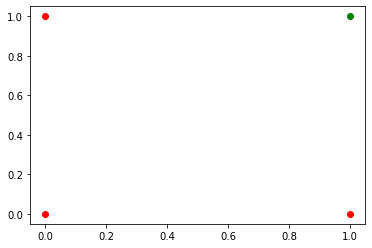

In [ ]:
plt.figure()

for i in range(len(Y)):
    if Y[i] == 0:
        plt.plot(X1[i], X2[i], "ro")
    else:
        plt.plot(X1[i], X2[i], "go")

plt.show()

In [ ]:
W = [random.random(), random.random()]
b = random.random()

print(W, b)

lr=0.02
theta=0.5

[0.10035610661047878, 0.2990192251365278] 0.3395712640627325


In [ ]:
epoch = 0
count = 0

while count < 4:

    total_error = 0
    print(f"Epoch: {epoch}")
    for i in range(len(X1)):
        weighted_sum = W[0]*X1[i] + W[1]*X2[i] + b
        pred = 0
        if weighted_sum > theta:
            pred = 1

        error =  Y[i] - pred
        if error != 0:
            count = 0
            total_error += math.sqrt(error**2)

            W[0] += lr * error * X1[i]
            W[1] += lr * error * X2[i]
            b    += lr * error
        else:
            count += 1

        print(f"[{X1[i]} , {X2[i]}] = {pred}")

    print(f"Loss: {total_error}")
    print("===------------------------------===")
    epoch += 1

Epoch: 0
[0 , 0] = 0
[0 , 1] = 1
[1 , 0] = 0
[1 , 1] = 1
Loss: 1.0
===------------------------------===
Epoch: 1
[0 , 0] = 0
[0 , 1] = 1
[1 , 0] = 0
[1 , 1] = 1
Loss: 1.0
===------------------------------===
Epoch: 2
[0 , 0] = 0
[0 , 1] = 1
[1 , 0] = 0
[1 , 1] = 1
Loss: 1.0
===------------------------------===
Epoch: 3
[0 , 0] = 0
[0 , 1] = 1
[1 , 0] = 0
[1 , 1] = 1
Loss: 1.0
===------------------------------===
Epoch: 4
[0 , 0] = 0
[0 , 1] = 0
[1 , 0] = 0
[1 , 1] = 1
Loss: 0
===------------------------------===


In [ ]:
print("W0 = ", W[0])
print("W1 = ", W[1])
print("b = ", b)

W0 =  0.10035610661047878
W1 =  0.21901922513652777
b =  0.25957126406273245


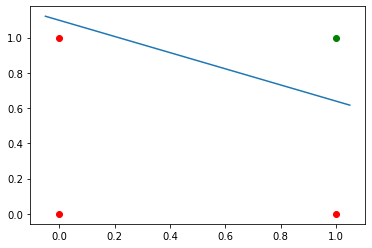

In [ ]:
plt.figure()

for i in range(len(Y)):
    if Y[i] == 0:
        plt.plot(X1[i], X2[i], "ro")
    else:
        plt.plot(X1[i], X2[i], "go")


xintr=(theta-b)/W[0]
yintr=(theta-b)/W[1]

slope=-yintr/xintr
xx=plt.xlim()
yeq = []
for x in xx:
    yeq.append(slope*x+yintr)
plt.plot(xx,yeq)
plt.show()

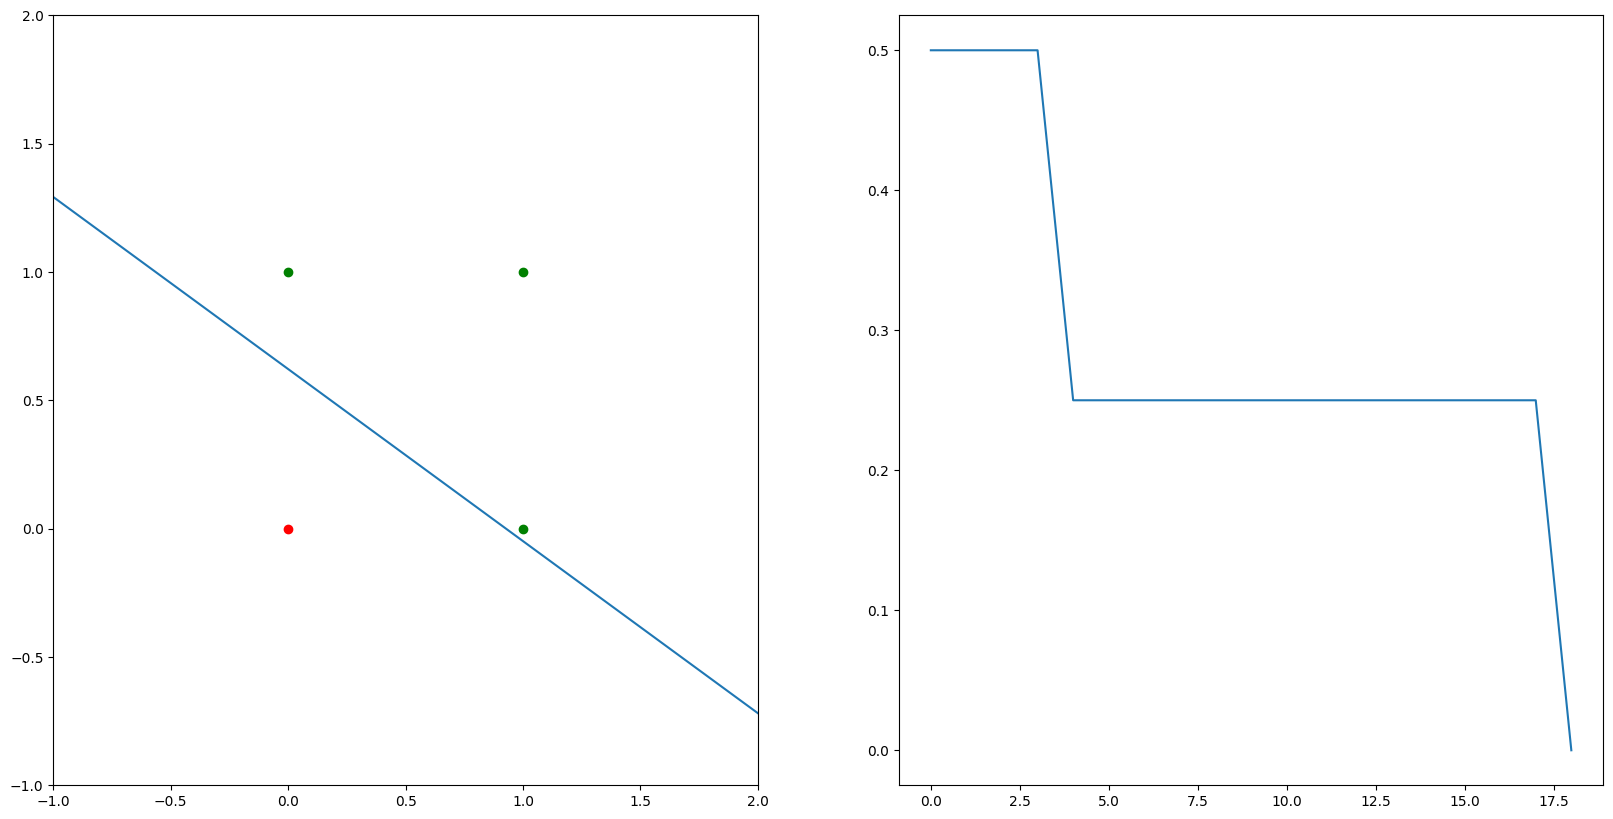

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math
from IPython import display

X1 = [0,0,1,1]
X2 = [0,1,0,1]
# Y  = [0,0,0,1] # AND
Y  = [0,1,1,1] # OR
# Y  = [0,1,1,0] # XOR

W = [random.random(), random.random()]
b = random.random()

# W = [random.uniform(-1,1), random.uniform(-1,1)]
# b = random.uniform(-1,1)

lr=0.01
theta=0.5
epoch = 0
count = 0

loss = []
while count < 4:

    total_error = 0
    for i in range(len(X1)):
        weighted_sum = W[0]*X1[i] + W[1]*X2[i] + b
        pred = 0
        if weighted_sum > theta:
            pred = 1

        error =  Y[i] - pred
        if error != 0:
            count = 0
            total_error += math.sqrt(error**2)

            W[0] += lr * error * X1[i]
            W[1] += lr * error * X2[i]
            b    += lr * error

        else:
            count += 1
    loss.append(1/4*total_error)

    plt.figure(figsize=(20,10))
    display.clear_output(wait=True)
    plt.subplot(1,2,1)
    for i in range(len(Y)):
        if Y[i] == 0:
            plt.plot(X1[i], X2[i], "ro")
        else:
            plt.plot(X1[i], X2[i], "go")
    plt.xlim([-1, 2])
    plt.ylim([-1, 2])

    xintr=(theta-b)/W[0]
    yintr=(theta-b)/W[1]

    slope=-yintr/xintr
    xx=plt.xlim()

    yeq = []
    for x in xx:
        yeq.append(slope*x+yintr)
    plt.plot(xx,yeq)


    plt.subplot(1,2,2)
    plt.plot(loss)

    plt.show()

    epoch += 1



In [ ]:
import pandas as pd

df = pd.read_csv('./resources/M_1A_data2.csv')
df.head()

,X,Y,LABEL
0,71,32,0
1,65,88,0
2,13,27,1
3,67,2,0
4,60,27,0


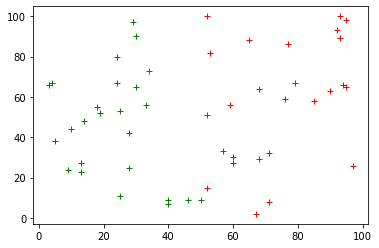

In [ ]:
X1 = df["X"].values.tolist()
X2 = df["Y"].values.tolist()
Y = df["LABEL"].values.tolist()

for i in range(len(Y)):
    if Y[i] == 0:
        plt.plot(X1[i], X2[i], "r+")
    else:
        plt.plot(X1[i], X2[i], "g+")


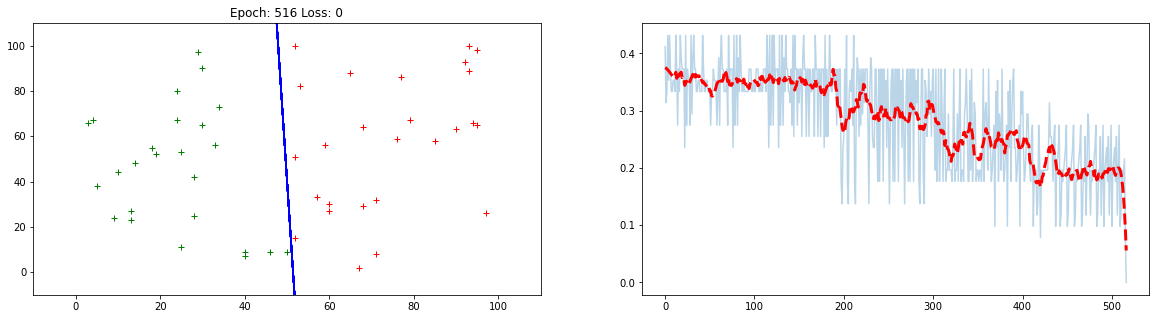

Epoch: 516 Loss: 0.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math
from IPython import display
from scipy.signal import savgol_filter


W = [random.random(), random.random()]
b = random.random()

# W = [random.uniform(-1,1), random.uniform(-1,1)]
# b = random.uniform(-1,1)

lr = 0.1
theta=0.5

epoch = 0
count = 0


loss = []

while count < len(X1):

    total_error = 0
    for i in range(len(X1)):
        weighted_sum = W[0]*X1[i] + W[1]*X2[i] + b
        pred = 0
        if weighted_sum > theta:
            pred = 1

        error =  Y[i] - pred
        if error != 0:
            count = 0
            total_error += math.sqrt(error**2)

            W[0] += lr * error * X1[i]
            W[1] += lr * error * X2[i]
            b    += lr * error
        else:
            count += 1

    loss.append(1/len(X1)*total_error)

    plt.figure(figsize=(20,5))
    #loss.append([epoch, total_error])
    display.clear_output(wait=True)
    plt.subplot(1,2,1)

    for i in range(len(Y)):
        if Y[i] == 0:
            plt.plot(X1[i], X2[i], "r+")
        else:
            plt.plot(X1[i], X2[i], "g+")

        plt.xlim([-10, 110])
        plt.ylim([-10, 110])

        xintr=(theta-b)/W[0]
        yintr=(theta-b)/W[1]

        slope = -yintr/xintr
        xx = plt.xlim()
#                 print(xx)
        yeq = []
        for x in xx:
            yeq.append(slope*x+yintr)
        plt.plot(xx,yeq, 'b-')

    plt.title(f"Epoch: {epoch} Loss: {total_error}")

    plt.subplot(1,2,2)
    plt.plot(loss, alpha=0.3)
    if epoch > 20:
        yhat = savgol_filter(loss, 21, 3) # window size 51, polynomial order 3
        plt.plot(yhat, 'r--', lw=3)

    plt.show()

    print(f"Epoch: {epoch} Loss: {loss[-1]}")
    epoch += 1

